# Installing and Using the bagelR Package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpJbYY9B/remotes19b098ada0441/grosed-bagel-b0aef6f/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.4.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.4.0’

## Using bagelR - 1 : Detecting Change in Mean

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example 1 - no change

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Generate some data - no change

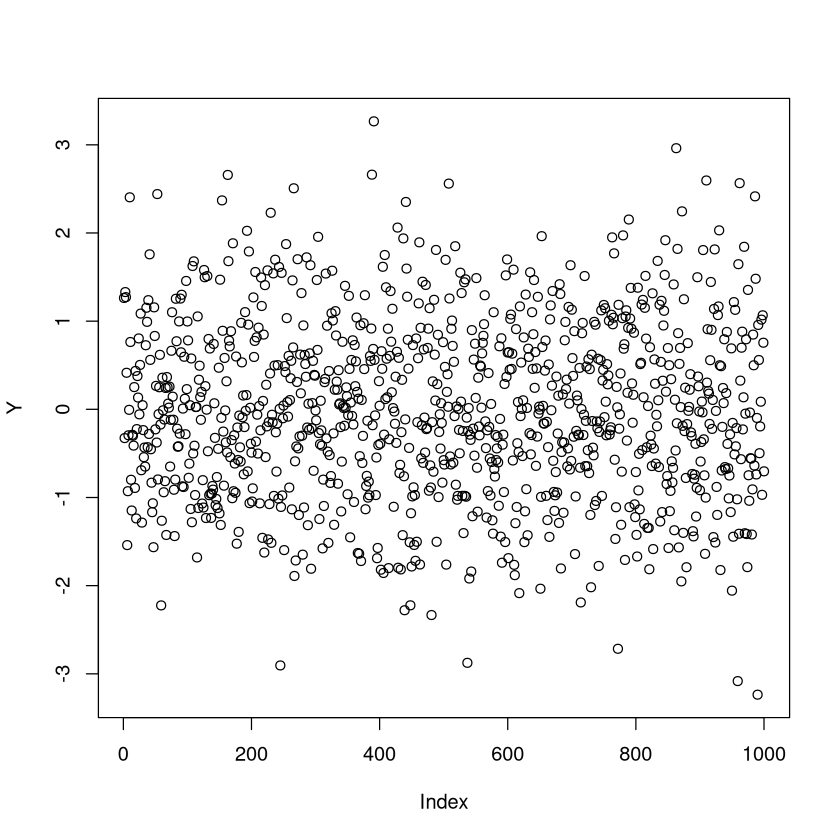

In [7]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Set model parameters 

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [9]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [10]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

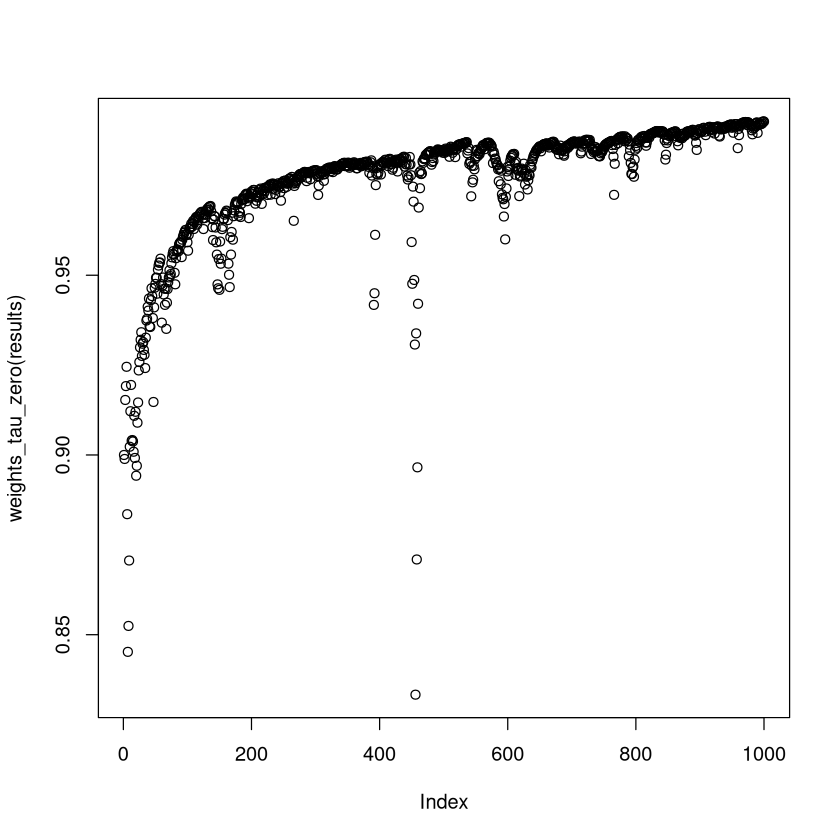

In [11]:
plot(weights_tau_zero(results))

#### Offline analysis - uknown variance

In [12]:
nu <- 1.0
iota <- 1.0

In [ ]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

### Example 2 - single change in mean

#### Generate some data - change at t = 501 

In [ ]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [ ]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [ ]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Example 3 - single change in mean different prior

#### Define new prior

In [ ]:
prior <- function(t)
{
  mu1<-1;
  delta1<-1
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta1*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- delta1*matrix(c(1,-1,-1,2),nr=2,nc=2)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Offline analysis - known variance

**Note** - _exact_ variation can be used since analysis is _univariate_ with _known variance_

In [ ]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [ ]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

## Using bagelR - 2 : Detecting Change in Slope

### Example 1 - no change

#### Generate some data - no change

In [ ]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [ ]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [ ]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transformation function

In [ ]:
transform <- function(tau)
{
	return(matrix(c(1,tau+1,1,tau+1,0,1,0,1),2,4,byrow=TRUE))
}

#### Set model parameters 

In [ ]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 250
threshold <- 0.8

#### Offline analysis - known variance

In [ ]:
results <- bagel_kv_approximate(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Offline analysis - unknown variance

In [ ]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

In [ ]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Offline analysis - known variance

In [ ]:
results <- bagel_kv_approximate(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [ ]:
results <- bagel_uv_approximate(Y,feature_vector,prior,transform,p0,p,nu,iota,max_particles,threshold)

#### Check for a changepoint

In [ ]:
changepoint(results)

#### Visualise weight at tau = 0

In [ ]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

In [ ]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Other methods

### Get the taus

- Returns a vector of tau values for the active (unpruned) particles

In [ ]:
taus(results)

### Get the ratios

- Returns a list of vectors containing the ratios for each active (unpruned) particle

In [ ]:
ratios <- ratios(results)
ratios[[44]]

### Get weights of active particles

- Returns a vector of weights for the currently active (unpruned) particles

In [ ]:
active_weights(results)